In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('zuu crew scores.csv')
df.head(5)

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
3,Nisal Gamage,1,74.5,63.9,7,0,76.8,1.7,Production-Ready ML Systems,100.0
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1


In [3]:
df = df[df['CourseName'] == 'Foundations of ML']
df.head()

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2


In [4]:
df['Passed'] = df['CapstoneScore'] > 50
df

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore,Passed
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3,False
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8,True
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4,True
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1,False
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2,True
...,...,...,...,...,...,...,...,...,...,...,...
138,Student_139,3,89.3,42.7,2,0,96.9,2.5,Foundations of ML,56.2,True
139,Student_140,2,68.6,97.5,7,0,75.0,5.0,Foundations of ML,83.6,True
144,Student_145,3,79.9,35.6,6,1,32.4,3.9,Foundations of ML,43.6,False
145,Student_146,3,83.9,13.3,6,0,48.9,2.9,Foundations of ML,31.9,False


In [5]:
X = df[ 'TotalHours' ].values.reshape(-1, 1)
Y = df[ 'Passed' ].values

In [6]:
Y

array([False,  True,  True, False,  True,  True, False,  True, False,
       False,  True, False, False,  True,  True, False,  True, False,
       False,  True,  True, False, False,  True,  True, False, False,
       False,  True, False,  True, False, False,  True,  True,  True,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True, False,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True, False,
        True, False, False,  True,  True,  True, False, False,  True])

In [7]:
def sigmoid(z):
    return 1 / ( 1 + np.exp(-z))

Z = np.array([-10000000000000000, 0, 10000000000000000])
for z in Z:
    print(f"z: {z} -> sigmoid(z): {sigmoid(z)}")

z: -10000000000000000 -> sigmoid(z): 0.0
z: 0 -> sigmoid(z): 0.5
z: 10000000000000000 -> sigmoid(z): 1.0


C:\Users\User\AppData\Local\Temp\ipykernel_2544\988052960.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / ( 1 + np.exp(-z))


In [8]:
def compute_cost(y_hat, Y):
    pos_component = np.sum(Y * np.log(y_hat))
    neg_component = np.sum((1 - Y) * (1 - np.log(y_hat)))

    m = len(Y)
    return (-1/m) * (pos_component + neg_component)

In [9]:
def compute_gradients(X, Y, y_hat):
    m = len(Y)

    """
    beta0, beta1
    """

    dJ_dbeta1 = (1 / m) * X.T.dot(y_hat - Y)
    dJ_dbeta0 = (1 / m) * np.sum(y_hat - Y)

    return dJ_dbeta0, dJ_dbeta1

In [10]:
beta = np.random.randn(2)
print(f"Initial beta: {beta}")

beta0 = beta[0]
beta1 = beta[1]

lr = 0.000001
n_iter = 1000

Initial beta: [-0.14156418 -0.18963775]


In [12]:
cost_history = []

for i in range(n_iter):
    """
    
    z = beta.T.x = beta0 + beta1.x1
    Y_hat = sigmoid(z)
    """

    z = beta0 + X.dot(beta1)
    y_hat = sigmoid(z)

    dJ_dbeta0, dJ_dbeta1 = compute_gradients(X, Y, y_hat)

    beta0 = beta0 - lr * dJ_dbeta0
    beta1 = beta1 - lr * dJ_dbeta1

    cost = compute_cost(y_hat, Y)
    cost_history.append(cost)

    if i % 100 == 0:
        print(f"Iteration : {i}: Cost : {cost:.4f}")

Iteration : 0: Cost : 99.5144
Iteration : 100: Cost : 86.2704
Iteration : 200: Cost : 73.0317
Iteration : 300: Cost : 59.7988
Iteration : 400: Cost : 46.5726
Iteration : 500: Cost : 33.3537
Iteration : 600: Cost : 20.1432
Iteration : 700: Cost : 6.9421
Iteration : 800: Cost : -6.2483
Iteration : 900: Cost : -19.4264


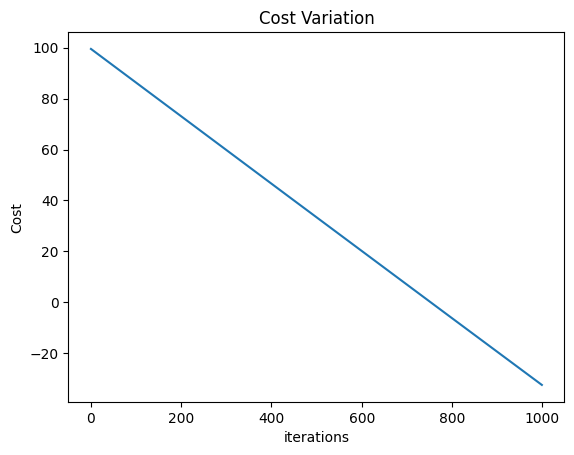

In [13]:
plt.plot(cost_history)
plt.title("Cost Variation")
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.show()

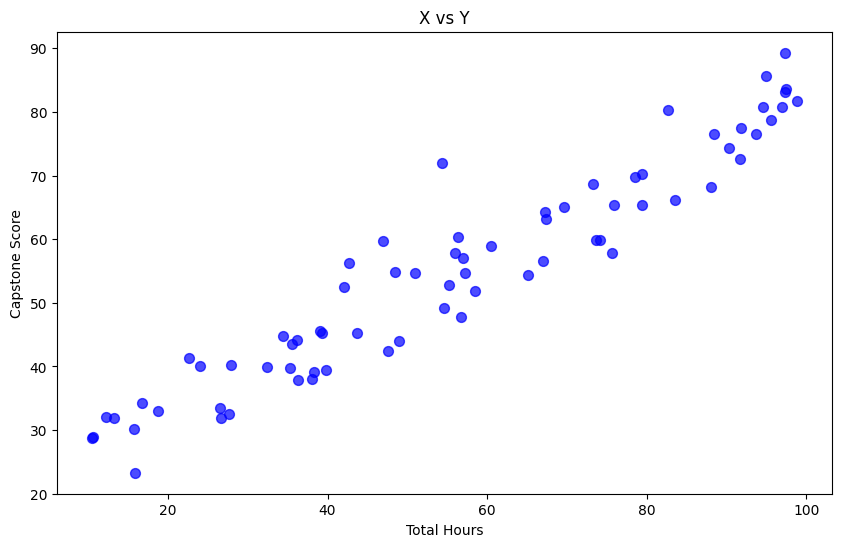

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.7, color='blue', s=50)
plt.xlabel('Total Hours')
plt.ylabel('Capstone Score')
plt.title('X vs Y')
plt.show()

In [ ]:
def compute_cost(X, Y, beta):
    """ 
        X : (m, n)
        Y : (m, )
        beta : (beta0, beta1)

        MSE = >  sum(( y_hat - y ) ** 2)
        X.dot(beta) => beta0 + beta1.x1 + ...... + betaj.xj + ...... + betan.xn   
    """

    m= len(Y)
    y_hat = X.dot(beta)
    cost = ( 1 / (2 * m) ) * np.sum((y_hat - Y) ** 2)
    return cost

def gradient_descent(X, Y, beta, lr, n_iter):
    """ 
    X : (m, n) -> after adding bias : (m, n+1) -> (72, 2) | If I take transpose -> (2, 72)

    dj/dbetaj = (1 / m) * X.T * (y_hat - y)
    """

    m = len(Y)
    cost_history = []

    for i in range(n_iter):

        y_hat = X.dot(beta)
        gradients = (1 / m) * X.T.dot(y_hat - Y)

        beta = beta - lr * gradients
        cost = compute_cost(X, Y, beta)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration: {i}: cost: {cost:.4f} ")

    return cost_history,beta     

In [ ]:
""" 
    y_hat = beta0.x0 + beta1.x1; xo = 1
    X = [1, x1]

"""


X_with_bias = np.column_stack([np.ones((len(X))), X])
X_with_bias

array([[ 1. , 43.7],
       [ 1. , 95.6],
       [ 1. , 75.9],
       [ 1. , 24. ],
       [ 1. , 88. ],
       [ 1. , 97.3],
       [ 1. , 26.5],
       [ 1. , 57.2],
       [ 1. , 48.9],
       [ 1. , 36.2],
       [ 1. , 65.1],
       [ 1. , 22.6],
       [ 1. , 36.3],
       [ 1. , 51. ],
       [ 1. , 56.3],
       [ 1. , 15.9],
       [ 1. , 96.9],
       [ 1. , 18.8],
       [ 1. , 54.6],
       [ 1. , 91.8],
       [ 1. , 69.6],
       [ 1. , 38.1],
       [ 1. , 26.6],
       [ 1. , 97.3],
       [ 1. , 94.6],
       [ 1. , 27.6],
       [ 1. , 39.3],
       [ 1. , 34.4],
       [ 1. , 42.1],
       [ 1. , 35.3],
       [ 1. , 98.8],
       [ 1. , 27.9],
       [ 1. , 10.5],
       [ 1. , 73.6],
       [ 1. , 75.6],
       [ 1. , 79.4],
       [ 1. , 16.7],
       [ 1. , 39.8],
       [ 1. , 15.7],
       [ 1. , 67.4],
       [ 1. , 74.2],
       [ 1. , 78.5],
       [ 1. , 60.5],
       [ 1. , 79.4],
       [ 1. , 54.4],
       [ 1. , 57. ],
       [ 1. , 48.5],
       [ 1. ,

In [ ]:
beta = np.random.randn(2)
print(f"beta values : {beta}")

lr = 0.000001
n_iter = 10000

beta values : [-0.52537338  1.76024973]


In [ ]:
cost_history, beta = gradient_descent(X_with_bias, Y, beta, lr, n_iter)

Iteration: 0: cost: 1395.1322 
Iteration: 100: cost: 673.9964 
Iteration: 200: cost: 340.5815 
Iteration: 300: cost: 186.4277 
Iteration: 400: cost: 115.1546 
Iteration: 500: cost: 82.2010 
Iteration: 600: cost: 66.9642 
Iteration: 700: cost: 59.9187 
Iteration: 800: cost: 56.6604 
Iteration: 900: cost: 55.1532 
Iteration: 1000: cost: 54.4555 
Iteration: 1100: cost: 54.1321 
Iteration: 1200: cost: 53.9818 
Iteration: 1300: cost: 53.9115 
Iteration: 1400: cost: 53.8782 
Iteration: 1500: cost: 53.8620 
Iteration: 1600: cost: 53.8537 
Iteration: 1700: cost: 53.8490 
Iteration: 1800: cost: 53.8461 
Iteration: 1900: cost: 53.8439 
Iteration: 2000: cost: 53.8421 
Iteration: 2100: cost: 53.8404 
Iteration: 2200: cost: 53.8389 
Iteration: 2300: cost: 53.8373 
Iteration: 2400: cost: 53.8358 
Iteration: 2500: cost: 53.8343 
Iteration: 2600: cost: 53.8328 
Iteration: 2700: cost: 53.8313 
Iteration: 2800: cost: 53.8298 
Iteration: 2900: cost: 53.8283 
Iteration: 3000: cost: 53.8268 
Iteration: 310

In [ ]:
print(f"beat beta : {beta}")

beat beta : [-0.49884706  0.9218035 ]


In [ ]:
x_min, x_max = float(np.min(X)), float(np.max(X))
x_interval = np.linspace(x_min, x_max, 100)
x_interval_with_bias = np.column_stack([np.ones((len(x_interval))), x_interval])
y_hat_interval = x_interval_with_bias.dot(beta)
y_hat_interval

array([ 9.18008969, 10.00226393, 10.82443816, 11.64661239, 12.46878663,
       13.29096086, 14.11313509, 14.93530932, 15.75748356, 16.57965779,
       17.40183202, 18.22400626, 19.04618049, 19.86835472, 20.69052895,
       21.51270319, 22.33487742, 23.15705165, 23.97922589, 24.80140012,
       25.62357435, 26.44574858, 27.26792282, 28.09009705, 28.91227128,
       29.73444552, 30.55661975, 31.37879398, 32.20096821, 33.02314245,
       33.84531668, 34.66749091, 35.48966515, 36.31183938, 37.13401361,
       37.95618784, 38.77836208, 39.60053631, 40.42271054, 41.24488478,
       42.06705901, 42.88923324, 43.71140748, 44.53358171, 45.35575594,
       46.17793017, 47.00010441, 47.82227864, 48.64445287, 49.46662711,
       50.28880134, 51.11097557, 51.9331498 , 52.75532404, 53.57749827,
       54.3996725 , 55.22184674, 56.04402097, 56.8661952 , 57.68836943,
       58.51054367, 59.3327179 , 60.15489213, 60.97706637, 61.7992406 ,
       62.62141483, 63.44358906, 64.2657633 , 65.08793753, 65.91

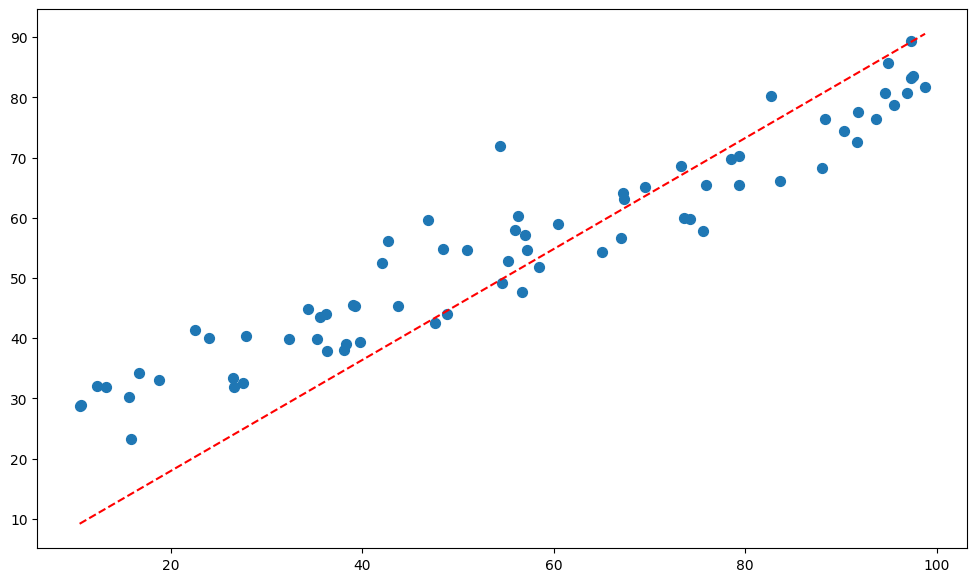

In [ ]:
plt.figure(figsize=(12, 7))

plt.scatter(X, Y, s=50, label="actual data")

plt.plot(x_interval, y_hat_interval, 'r--', label="fitted line")

plt.show()

##### how to evaluate ?

    - MSE : Mean squared error
    - RMSE : Root mean squared error
    - MAE : Mean absolute error
    - R^2 : R-squared